Notebook para modelo de Red neuronal

In [33]:
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (
    StandardScaler,
    MinMaxScaler,
    OneHotEncoder,
    OrdinalEncoder
)
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    auc,
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    roc_curve,
    roc_auc_score,
    mean_squared_error, mean_absolute_error, r2_score
)
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer

In [34]:
# df = pd.read_csv("../../data/processed/.csv")
df = pd.read_csv("../../data/raw/dataset_practica_final.csv")

In [35]:
categorical_columns = ["hotel", "arrival_date_month", "meal", "country", "market_segment", "distribution_channel", "is_repeated_guest", "reserved_room_type", "assigned_room_type", "deposit_type", "customer_type"]
numerical_columns = ["lead_time", "arrival_date_year", "arrival_date_week_number", "arrival_date_day_of_month", "stays_in_weekend_nights", "stays_in_week_nights", "adults", "children", "babies", "is_repeated_guest", "previous_cancellations", "previous_bookings_not_canceled", "booking_changes", "agent", "days_in_waiting_list", "adr", "required_car_parking_spaces", "total_of_special_requests"]                                  

In [36]:
numerical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numerical_transformer, numerical_columns),
    ("cat", categorical_transformer, categorical_columns)
])

In [37]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

In [38]:
X = df.drop(columns=["is_canceled", "company", "reservation_status", "reservation_status_date"])
y = df["is_canceled"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.2, random_state=42, stratify=y)

X_train_preprocessed = preprocessor.fit_transform(X_train)
X_test_preprocessed = preprocessor.transform(X_test)

In [39]:
X_train_preprocessed.shape

(95512, 253)

In [40]:
X_test_preprocessed.shape

(23878, 253)

In [42]:
dict_parametros = {
    'C': [0.01, 0.1, 1],
    'max_iter': [100, 200],
    'solver': ['liblinear']
}

modelo_rl = LogisticRegression(random_state=42)
modelo_rl_cv = GridSearchCV(modelo_rl, dict_parametros, cv=5, scoring='f1')
modelo_rl_cv.fit(X_train_preprocessed, y_train)

GridSearchCV(cv=5, estimator=LogisticRegression(random_state=42),
             param_grid={'C': [0.01, 0.1, 1], 'max_iter': [100, 200],
                         'solver': ['liblinear']},
             scoring='f1')

In [43]:
print(f"Mejores hiperparámetros encontrados: {modelo_rl_cv.best_params_}")
print(f"Mejor score obtenido: {modelo_rl_cv.best_score_:.2%}")

Mejores hiperparámetros encontrados: {'C': 1, 'max_iter': 100, 'solver': 'liblinear'}
Mejor score obtenido: 73.02%


In [25]:
modelo_rl = LogisticRegression(C=1, max_iter=100, solver='liblinear')
modelo_rl.fit(X_train_preprocessed, y_train)

LogisticRegression(C=1, solver='liblinear')

In [26]:
y_pred = modelo_rl.predict(X_test_preprocessed)

In [27]:
y_proba = modelo_rl.predict_proba(X_test_preprocessed)[:, 1]

In [28]:
# Obtención de las métricas de evaluación
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

# Cálculo del AUC (Area Under the Curve)
auc = roc_auc_score(y_test, y_proba)

print(f"Accuracy:  {acc:.2%}")
print(f"Precisión: {prec:.2%}")
print(f"Recall:    {rec:.2f}")
print(f"F1-Score:  {f1:.2f}")
print(f"AUC:       {auc:.2f}\n")

Accuracy:  81.90%
Precisión: 81.26%
Recall:    0.66
F1-Score:  0.73
AUC:       0.90



In [29]:
# Gracias a la función classification_report podemos obtener un reporte detallado de las métricas de evaluación
print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred))


Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.82      0.91      0.86     15033
           1       0.81      0.66      0.73      8845

    accuracy                           0.82     23878
   macro avg       0.82      0.79      0.80     23878
weighted avg       0.82      0.82      0.81     23878



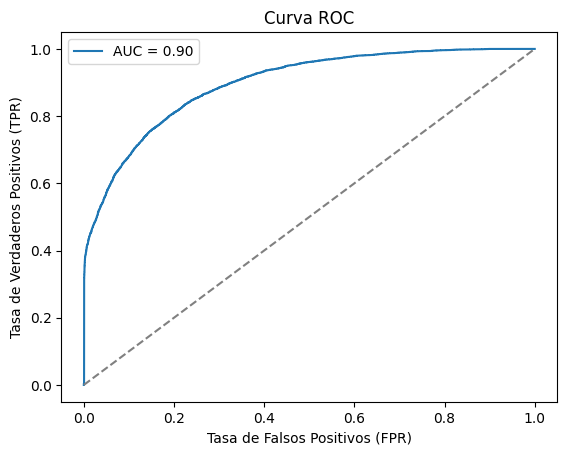

In [31]:
# Curva ROC
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
plt.plot(fpr, tpr, label=f'AUC = {auc:.2f}')
plt.plot([0, 1], [0, 1], linestyle='--', color='grey')
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title('Curva ROC')
plt.legend()
plt.show()

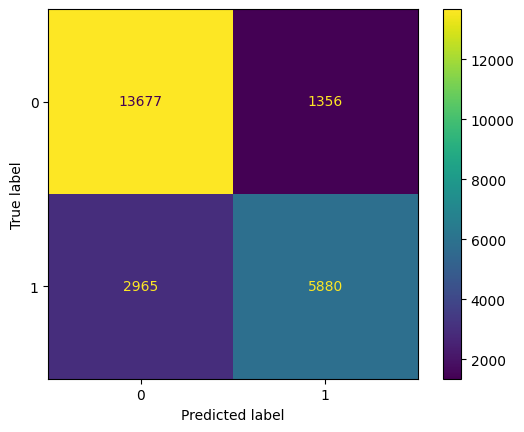

In [32]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred
)